# Gaia DR3 colour–magnitude diagram

## A reproducible stellar-population analysis

This notebook turns a Gaia DR3 sample into a quality-controlled colour–magnitude diagram (CMD). It is organised as a guided, top-to-bottom analysis rather than a record of every exploratory step.

### At a glance

Using the supplied 5,000-row Gaia archive snapshot, the completed analysis finds:

- 4,681 quality-controlled sources after the BP/RP photometric-quality cut;
- 59 white-dwarf candidates and 189 high-luminosity candidates;
- 4,211 sources in the main-sequence working region;
- a third-order empirical main-sequence ridge with RMSE = 0.120 mag;
- 157 faint-side residual outliers, falling to 20 under a stricter parallax signal-to-noise requirement.

**How to use this notebook:** run the cells in order, from top to bottom. Short explanations before each step say what the code does and what you should check. The stored data file is deliberately used instead of re-querying Gaia, so the results remain reproducible.

## 1. Introduction

### Research question

Can Gaia DR3 astrometry and photometry be used to construct a quality-controlled CMD, identify broad stellar-population regions, and quantitatively describe the observed main sequence?

A CMD plots Gaia colour, \(BP-RP\), against absolute G-band magnitude, \(M_G\). Smaller colour values are generally bluer; smaller absolute magnitudes are intrinsically brighter.

### Key assumptions and limits

- Distances use direct parallax inversion, \(d=1000/\varpi\), with \(\varpi\) in milliarcseconds. This is appropriate here because the input query requires parallax S/N > 5; it is not a general distance estimator for low-S/N stars.
- No extinction or reddening correction is applied. The sample is nearby (parallax > 2 mas, approximately within 500 pc), but extinction is not necessarily zero.
- The white-dwarf and high-luminosity selections identify **candidates**, not definitive stellar classifications.
- The supplied Gaia table is a fixed 5,000-row archive snapshot. Its original retrieval time was not recorded, so this notebook reports the snapshot rather than claiming a live Gaia Archive "as of" date.

In [1]:
# Imports and project settings. Run this once at the beginning.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

PROJECT_ROOT = Path.cwd()
DATA_PATH = Path(
    "/Users/shiljojohnsebastian/Desktop/downloads drive/gaia_dr3_initial_5000.ecsv"
)

REQUIRED_COLUMNS = [
    "SOURCE_ID",
    "parallax",
    "parallax_error",
    "phot_g_mean_mag",
    "phot_bp_mean_mag",
    "phot_rp_mean_mag",
    "phot_bp_rp_excess_factor",
    "ruwe",
    "visibility_periods_used",
]

assert DATA_PATH.exists(), (
    f"Could not find {DATA_PATH}. Keep the supplied ECSV file in the data folder."
)

## 2. Gaia data query

The original sample was queried from `gaiadr3.gaia_source` through the Gaia Archive. The ADQL query below is retained as provenance, but it is **not run** during the normal workflow: `TOP 5000` without a stable ordering can return a different subset on a later live query.

The accompanying ECSV file is therefore the reproducible input. If you intentionally want a new sample, use the optional download function only after changing the output filename and recording the retrieval date.

In [2]:
# Original Gaia DR3 query, retained for provenance.
ADQL_QUERY = """
SELECT TOP 5000
    source_id,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    phot_bp_rp_excess_factor,
    ruwe,
    visibility_periods_used
FROM gaiadr3.gaia_source
WHERE parallax > 2
  AND parallax_over_error > 5
  AND ruwe < 1.4
  AND visibility_periods_used >= 8
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
"""


def download_new_gaia_snapshot(output_path: Path):
    """Optional: download and save a new Gaia sample with the ADQL query above."""
    from astroquery.gaia import Gaia  # Needed only for a new live download.

    job = Gaia.launch_job(ADQL_QUERY)
    downloaded_data = job.get_results()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    downloaded_data.write(output_path, format="ascii.ecsv", overwrite=False)
    return downloaded_data

## 3. Initial sample

Load the fixed input table and confirm its basic integrity. The query applies the parallax, RUWE, and visibility-period requirements at retrieval time, so the 5,000-row table is the **initial analysis sample**, not an unfiltered Gaia catalogue.

**What to check:** 5,000 unique sources, the expected columns, no missing numerical values, and all query-level quality requirements satisfied.

In [3]:
initial_data = Table.read(DATA_PATH, format="ascii.ecsv")

missing_columns = [column for column in REQUIRED_COLUMNS if column not in initial_data.colnames]
assert not missing_columns, f"Missing required columns: {missing_columns}"
assert len(initial_data) == 5000, "This notebook expects the supplied 5,000-row snapshot."
assert len(np.unique(initial_data["SOURCE_ID"])) == len(initial_data), "Duplicate Gaia source IDs found."

numeric_columns = [column for column in REQUIRED_COLUMNS if column != "SOURCE_ID"]
non_finite = {
    column: int(np.sum(~np.isfinite(np.asarray(initial_data[column], dtype=float))))
    for column in numeric_columns
}
assert all(count == 0 for count in non_finite.values()), f"Non-finite values found: {non_finite}"

initial_parallax_snr = initial_data["parallax"] / initial_data["parallax_error"]
assert np.all(initial_data["parallax"] > 2)
assert np.all(initial_parallax_snr > 5)
assert np.all(initial_data["ruwe"] < 1.4)
assert np.all(initial_data["visibility_periods_used"] >= 8)

print(f"Initial sample: {len(initial_data):,} unique Gaia DR3 sources")
print("All query-level quality requirements are satisfied.")
initial_data[:3]

Initial sample: 5,000 unique Gaia DR3 sources
All query-level quality requirements are satisfied.


SOURCE_ID,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,phot_bp_rp_excess_factor,ruwe,visibility_periods_used
,mas,mas,mag,mag,mag,,,
int64,float64,float32,float32,float32,float32,float32,float32,int16
137341681052910080,2.515426516258834,0.016483681,13.132419,13.643993,12.462868,1.232618,0.9827368,14
137352882328671744,4.783345894183048,0.13884436,18.138844,19.921902,16.906704,1.4497465,0.9442937,14
137356696259645056,3.055982055945851,0.2001097,18.55162,20.185564,17.323345,1.4657558,0.96664566,15


## 4. Quality control

Gaia's `phot_bp_rp_excess_factor` checks the consistency of BP/RP photometry with the G band. Because its expected value changes with colour, we first calculate the colour-corrected quantity \(C^*\) using the piecewise Gaia DR3 prescription.

We then retain sources with \(-0.08 < C^* < 0.20\). This fixed boundary is a documented project choice; it is not a universal Gaia rule. The query-level astrometric cuts are already present in the initial sample, while this is the additional post-query photometric cut.

In [4]:
# Calculate the Gaia DR3 colour-corrected BP/RP flux-excess factor, C*.
bp_rp_initial = np.asarray(
    initial_data["phot_bp_mean_mag"] - initial_data["phot_rp_mean_mag"],
    dtype=float,
)
excess_factor = np.asarray(initial_data["phot_bp_rp_excess_factor"], dtype=float)

c_star = np.empty(len(initial_data), dtype=float)
blue = bp_rp_initial < 0.5
green = (bp_rp_initial >= 0.5) & (bp_rp_initial < 4.0)
red = bp_rp_initial >= 4.0

c_star[blue] = excess_factor[blue] - (
    1.154360 + 0.033772 * bp_rp_initial[blue] + 0.032277 * bp_rp_initial[blue] ** 2
)
c_star[green] = excess_factor[green] - (
    1.162004
    + 0.011464 * bp_rp_initial[green]
    + 0.049255 * bp_rp_initial[green] ** 2
    - 0.005879 * bp_rp_initial[green] ** 3
)
c_star[red] = excess_factor[red] - (
    1.057572 + 0.140537 * bp_rp_initial[red]
)

good_photometry = (c_star > -0.08) & (c_star < 0.20)
final_data = initial_data[good_photometry]

print(f"Sources passing the C* cut: {len(final_data):,}")
print(f"Sources removed by the C* cut: {len(initial_data) - len(final_data):,}")

Sources passing the C* cut: 4,681
Sources removed by the C* cut: 319


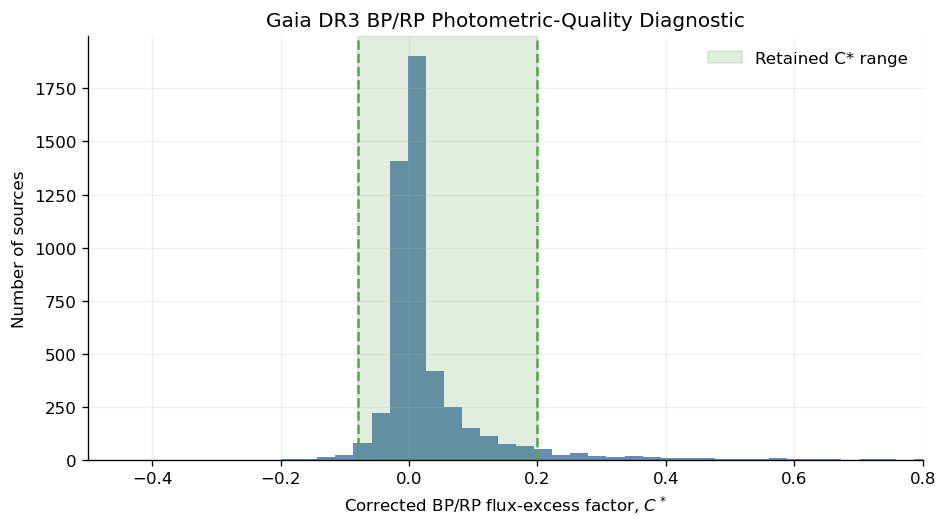

In [5]:
# Retained diagnostic: it shows the photometric-quality selection transparently.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(c_star, bins=100, color="#4C78A8", alpha=0.85)
ax.axvspan(-0.08, 0.20, color="#59A14F", alpha=0.18, label="Retained C* range")
ax.axvline(-0.08, color="#59A14F", linestyle="--")
ax.axvline(0.20, color="#59A14F", linestyle="--")
ax.set_xlim(-0.5, 0.8)
ax.set_xlabel(r"Corrected BP/RP flux-excess factor, $C^*$")
ax.set_ylabel("Number of sources")
ax.set_title("Gaia DR3 BP/RP Photometric-Quality Diagnostic")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Derived quantities

Build one analysis table that keeps the original Gaia measurements, quality diagnostics, and derived CMD coordinates together.

For each source:

\[
d\,(\mathrm{pc})=\frac{1000}{\varpi\,(\mathrm{mas})},\qquad
BP-RP=m_{BP}-m_{RP},\qquad
M_G=m_G-5\log_{10}(d)+5.
\]

**What to check:** all distances are positive, all CMD coordinates are finite, and the table has 4,681 rows.

In [6]:
final_distance_pc = 1000 / np.asarray(final_data["parallax"], dtype=float)
final_colour = np.asarray(
    final_data["phot_bp_mean_mag"] - final_data["phot_rp_mean_mag"], dtype=float
)
final_absolute_mag = (
    np.asarray(final_data["phot_g_mean_mag"], dtype=float)
    - 5 * np.log10(final_distance_pc)
    + 5
)

final_analysis = Table()
final_analysis["source_id"] = final_data["SOURCE_ID"]
final_analysis["parallax"] = final_data["parallax"]
final_analysis["parallax_error"] = final_data["parallax_error"]
final_analysis["parallax_snr"] = final_data["parallax"] / final_data["parallax_error"]
final_analysis["ruwe"] = final_data["ruwe"]
final_analysis["visibility_periods_used"] = final_data["visibility_periods_used"]
final_analysis["C_star"] = c_star[good_photometry]
final_analysis["G"] = final_data["phot_g_mean_mag"]
final_analysis["BP"] = final_data["phot_bp_mean_mag"]
final_analysis["RP"] = final_data["phot_rp_mean_mag"]
final_analysis["distance_pc"] = final_distance_pc
final_analysis["BP_RP"] = final_colour
final_analysis["M_G"] = final_absolute_mag

assert len(final_analysis) == 4681
assert np.all(final_analysis["distance_pc"] > 0)
assert np.all(np.isfinite(final_analysis["BP_RP"]))
assert np.all(np.isfinite(final_analysis["M_G"]))

print(f"Final analysis sample: {len(final_analysis):,} sources")
print(f"Absolute G-magnitude range: {np.min(final_analysis['M_G']):.2f} to {np.max(final_analysis['M_G']):.2f}")
final_analysis[:5]

Final analysis sample: 4,681 sources
Absolute G-magnitude range: -1.61 to 16.25


source_id,parallax,parallax_error,parallax_snr,ruwe,visibility_periods_used,C_star,G,BP,RP,distance_pc,BP_RP,M_G
,mas,mas,mas,,,,mag,mag,mag,,,
int64,float64,float32,float64,float32,int16,float64,float32,float32,float32,float64,float64,float64
137341681052910080,2.515426516258834,0.016483681,152.6010163672613,0.9827368,14,-0.0019529662726784913,13.132419,13.643993,12.462868,397.5468945470484,1.1811256408691406,5.1354768060130525
137352882328671744,4.783345894183048,0.13884436,34.45113675504324,0.9442937,14,-0.03346387959766295,18.138844,19.921902,16.906704,209.0586844693971,3.01519775390625,11.5375024703244
137356696259645056,3.055982055945851,0.2001097,15.271533436733677,0.96664566,15,0.005279417502563888,18.55162,20.185564,17.323345,327.2270522840135,2.8622188568115234,10.977374482545986
137357623972593664,2.9106306726217293,0.111693054,26.059191301343184,1.0311307,14,-0.0027855054590659734,17.75437,18.979937,16.6714,343.5681515371572,2.3085365295410156,10.074305244158348
138825575073994752,2.3942168693354127,0.38212913,6.265465425575134,1.0856813,14,-0.05738912513481842,19.249615,21.39838,17.954195,417.6731075650554,3.444185256958008,11.145432147870208


## 6. Final CMD

The final CMD shows the quality-controlled Gaia population. The magnitude axis is inverted so intrinsically brighter stars appear at the top, following astronomical convention.

The density view is retained because it reveals where the population is concentrated; it is a complement to the individual-source CMD, not an exploratory duplicate.

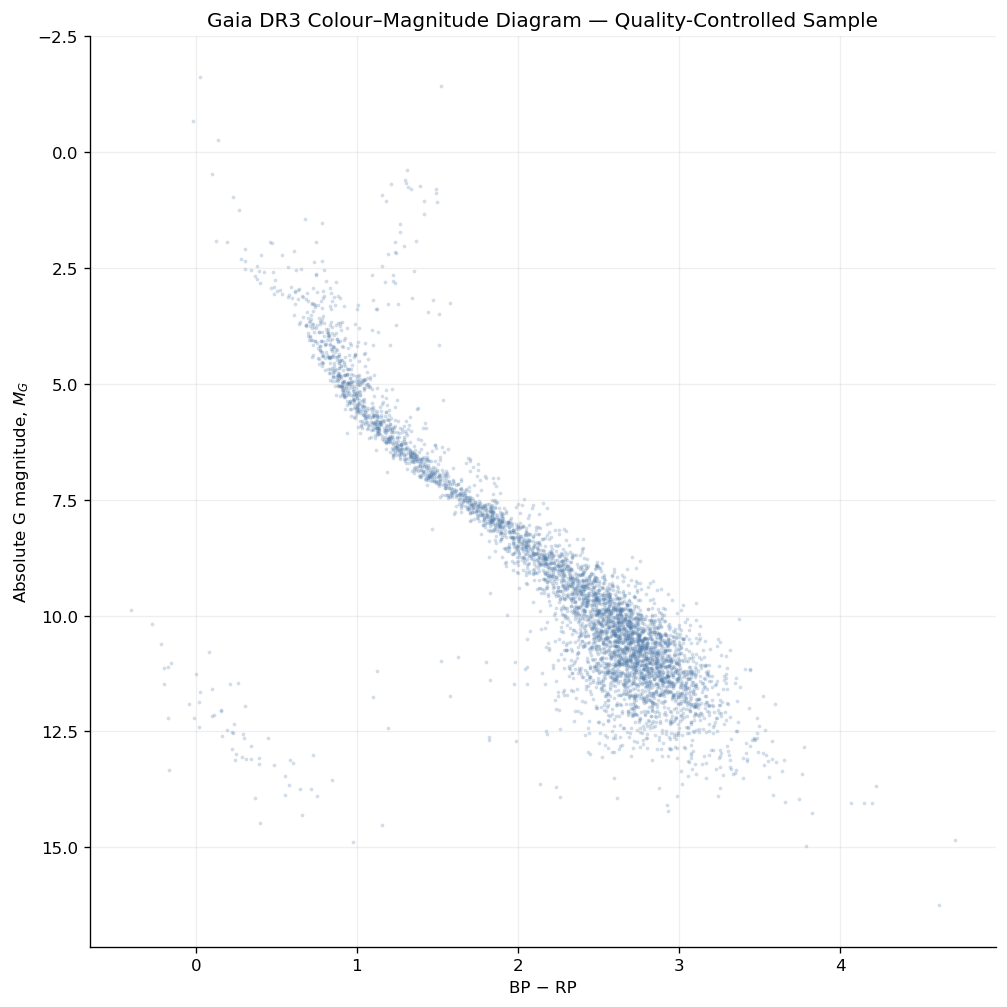

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.scatter(
    final_analysis["BP_RP"],
    final_analysis["M_G"],
    s=5,
    alpha=0.25,
    color="#4C78A8",
    linewidths=0,
)
ax.set_xlabel("BP − RP")
ax.set_ylabel(r"Absolute G magnitude, $M_G$")
ax.set_title("Gaia DR3 Colour–Magnitude Diagram — Quality-Controlled Sample")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

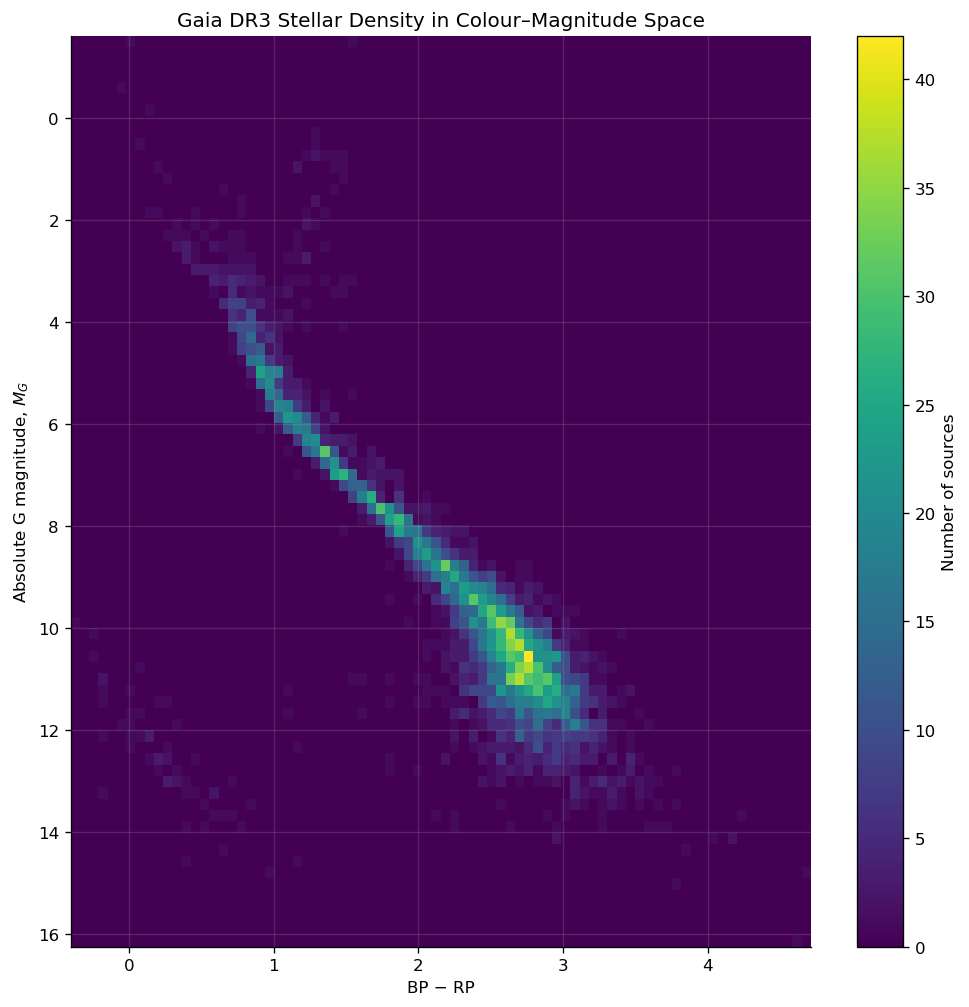

In [8]:
density, colour_edges, magnitude_edges = np.histogram2d(
    final_analysis["BP_RP"], final_analysis["M_G"], bins=(80, 80)
)

fig, ax = plt.subplots(figsize=(8.5, 8.5))
image = ax.pcolormesh(colour_edges, magnitude_edges, density.T, cmap="viridis")
ax.set_xlabel("BP − RP")
ax.set_ylabel(r"Absolute G magnitude, $M_G$")
ax.set_title("Gaia DR3 Stellar Density in Colour–Magnitude Space")
ax.invert_yaxis()
fig.colorbar(image, ax=ax, label="Number of sources")
plt.tight_layout()
plt.show()

## 7. Population analysis

The following working regions are deliberately simple and reproducible:

- **White-dwarf candidates:** \(M_G > 6 + 5(BP-RP)\) and \(BP-RP<1.5\).
- **High-luminosity candidates:** \(M_G<4\).
- **Main-sequence working region:** \(0.5<BP-RP<3.2\) and \(4<M_G<12.5\).

These regions are not a complete, mutually exclusive classification system. In particular, the main-sequence region is a practical domain for fitting a ridge, not a claim that every selected object is unevolved.

In [9]:
wd_candidates = (
    (final_analysis["M_G"] > 6 + 5 * final_analysis["BP_RP"])
    & (final_analysis["BP_RP"] < 1.5)
)
high_luminosity = final_analysis["M_G"] < 4
main_sequence_mask = (
    (final_analysis["BP_RP"] > 0.5)
    & (final_analysis["BP_RP"] < 3.2)
    & (final_analysis["M_G"] > 4)
    & (final_analysis["M_G"] < 12.5)
)

wd_data = final_analysis[wd_candidates]
high_lum_data = final_analysis[high_luminosity]
main_sequence_data = final_analysis[main_sequence_mask]

total_stars = len(final_analysis)
population_summary = Table(
    rows=[
        ("White-dwarf candidates", len(wd_data), 100 * len(wd_data) / total_stars),
        ("High-luminosity candidates", len(high_lum_data), 100 * len(high_lum_data) / total_stars),
        ("Main-sequence working sample", len(main_sequence_data), 100 * len(main_sequence_data) / total_stars),
    ],
    names=("Population", "Count", "Fraction_percent"),
)
population_summary["Fraction_percent"].format = ".2f"

print(population_summary)
print("White-dwarf/main-sequence working-region overlap:", int(np.sum(wd_candidates & main_sequence_mask)))
print("High-luminosity/main-sequence working-region overlap:", int(np.sum(high_luminosity & main_sequence_mask)))

         Population          Count Fraction_percent
---------------------------- ----- ----------------
      White-dwarf candidates    59             1.26
  High-luminosity candidates   189             4.04
Main-sequence working sample  4211            89.96
White-dwarf/main-sequence working-region overlap: 2
High-luminosity/main-sequence working-region overlap: 0


## 8. Main-sequence modelling

To estimate the main-sequence ridge, we take the median \(M_G\) in 39 colour bins across the working region and fit a third-order polynomial. The model is empirical: it describes this sample's central ridge and is not a universal stellar-evolution equation.

**What to check:** the measured ridge follows the dense sequence and the fitted curve remains close to it across the chosen colour range.

In [10]:
main_colour = np.asarray(main_sequence_data["BP_RP"], dtype=float)
main_mag = np.asarray(main_sequence_data["M_G"], dtype=float)

main_bins = np.linspace(0.5, 3.2, 40)
main_centres = 0.5 * (main_bins[:-1] + main_bins[1:])
main_median_mag = np.array([
    np.median(main_mag[(main_colour >= main_bins[i]) & (main_colour < main_bins[i + 1])])
    if np.any((main_colour >= main_bins[i]) & (main_colour < main_bins[i + 1]))
    else np.nan
    for i in range(len(main_bins) - 1)
])

valid_ridge_bins = np.isfinite(main_median_mag)
coefficients = np.polyfit(
    main_centres[valid_ridge_bins], main_median_mag[valid_ridge_bins], 3
)
fitted_ridge_mag = np.polyval(coefficients, main_centres[valid_ridge_bins])
ridge_residuals = main_median_mag[valid_ridge_bins] - fitted_ridge_mag

main_predicted_mag = np.polyval(coefficients, main_colour)
main_residuals = main_mag - main_predicted_mag
ridge_rmse = np.sqrt(np.mean(ridge_residuals**2))
main_scatter = np.std(main_residuals)
mad = np.median(np.abs(main_residuals - np.median(main_residuals)))
robust_scatter = 1.4826 * mad

print("Polynomial coefficients (highest power first):", coefficients)
print(f"Ridge-fit RMSE: {ridge_rmse:.3f} mag")
print(f"Individual-star scatter: {main_scatter:.3f} mag")
print(f"Robust observed scatter: {robust_scatter:.3f} mag")

Polynomial coefficients (highest power first): [ 0.01539883 -0.33714248  4.18312757  1.38585239]
Ridge-fit RMSE: 0.120 mag
Individual-star scatter: 0.663 mag
Robust observed scatter: 0.491 mag


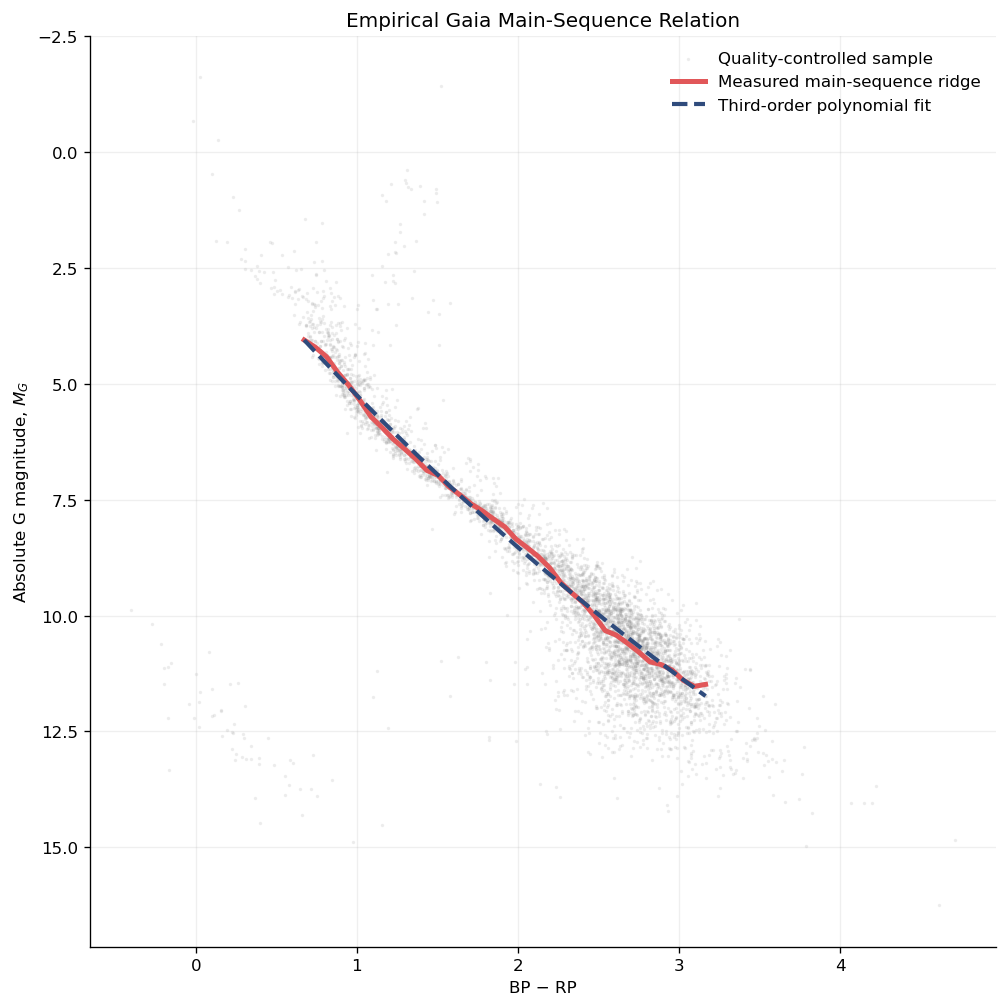

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.scatter(
    final_analysis["BP_RP"],
    final_analysis["M_G"],
    s=4,
    alpha=0.14,
    color="#7F7F7F",
    linewidths=0,
    label="Quality-controlled sample",
)
ax.plot(
    main_centres[valid_ridge_bins],
    main_median_mag[valid_ridge_bins],
    color="#E15759",
    linewidth=3,
    label="Measured main-sequence ridge",
)
ax.plot(
    main_centres[valid_ridge_bins],
    fitted_ridge_mag,
    color="#2F4B7C",
    linestyle="--",
    linewidth=2.5,
    label="Third-order polynomial fit",
)
ax.set_xlabel("BP − RP")
ax.set_ylabel(r"Absolute G magnitude, $M_G$")
ax.set_title("Empirical Gaia Main-Sequence Relation")
ax.invert_yaxis()
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 9. Robustness analysis

The individual-star residual is \(\Delta M_G=M_{G,\mathrm{observed}}-M_{G,\mathrm{fit}}\). We call \(|\Delta M_G|>1.5\) mag a strong residual outlier for diagnostic purposes only; we do not delete these sources automatically.

The sensitivity test strengthens the parallax threshold from S/N > 5 to S/N > 10 and checks how many faint-side residual outliers remain. This tests whether the broad faint-side tail is sensitive to distance precision.

In [12]:
outlier_mask = np.abs(main_residuals) > 1.5
faint_outliers = main_residuals > 1.5
bright_outliers = main_residuals < -1.5

high_snr_mask = final_analysis["parallax_snr"] > 10
high_snr_data = final_analysis[high_snr_mask]
faint_outlier_high_snr = faint_outliers & (main_sequence_data["parallax_snr"] > 10)
remaining_final = main_sequence_data[faint_outlier_high_snr]
remaining_mag_error = (
    5 / np.log(10) * remaining_final["parallax_error"] / remaining_final["parallax"]
)

print(f"Strong residual outliers: {int(np.sum(outlier_mask))}")
print(f"Faint-side / bright-side outliers: {int(np.sum(faint_outliers))} / {int(np.sum(bright_outliers))}")
print(f"Final-sample sources with parallax S/N > 10: {len(high_snr_data)}")
print(
    "Faint-side outliers retained at S/N > 10: "
    f"{int(np.sum(faint_outlier_high_snr))} "
    f"({100 * np.sum(faint_outlier_high_snr) / np.sum(faint_outliers):.1f}% of faint-side outliers)"
)
print(f"Remaining-outlier median parallax S/N: {np.median(remaining_final['parallax_snr']):.2f}")
print(f"Remaining-outlier median M_G uncertainty: {np.median(remaining_mag_error):.3f} mag")

Strong residual outliers: 171
Faint-side / bright-side outliers: 157 / 14
Final-sample sources with parallax S/N > 10: 3665
Faint-side outliers retained at S/N > 10: 20 (12.7% of faint-side outliers)
Remaining-outlier median parallax S/N: 12.16
Remaining-outlier median M_G uncertainty: 0.179 mag


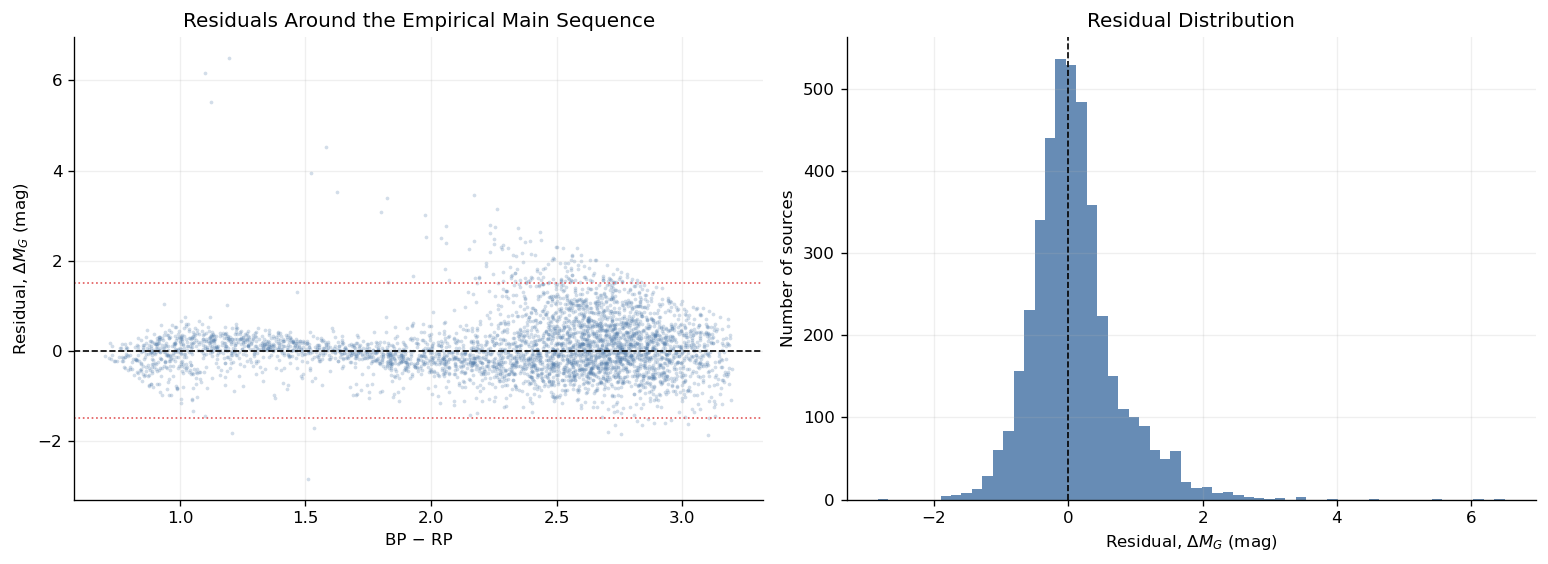

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(main_colour, main_residuals, s=5, alpha=0.25, color="#4C78A8", linewidths=0)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].axhline(1.5, color="#E15759", linestyle=":", linewidth=1)
axes[0].axhline(-1.5, color="#E15759", linestyle=":", linewidth=1)
axes[0].set_xlabel("BP − RP")
axes[0].set_ylabel(r"Residual, $\Delta M_G$ (mag)")
axes[0].set_title("Residuals Around the Empirical Main Sequence")

axes[1].hist(main_residuals, bins=60, color="#4C78A8", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"Residual, $\Delta M_G$ (mag)")
axes[1].set_ylabel("Number of sources")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 10. Final results

This section collects the values calculated above in one compact table and presents the final annotated CMD. Check the values against the headline results at the top of the notebook; matching values show that the supplied data snapshot has been processed correctly.

In [14]:
results_summary = Table(
    rows=[
        ("Initial Gaia snapshot", len(initial_data), "sources"),
        ("Final quality-controlled sample", len(final_analysis), "sources"),
        ("White-dwarf candidates", len(wd_data), f"{100 * len(wd_data) / total_stars:.2f}% of final sample"),
        ("High-luminosity candidates", len(high_lum_data), f"{100 * len(high_lum_data) / total_stars:.2f}% of final sample"),
        ("Main-sequence working sample", len(main_sequence_data), f"{100 * len(main_sequence_data) / total_stars:.2f}% of final sample"),
        ("Ridge-fit RMSE", ridge_rmse, "mag"),
        ("Robust observed scatter", robust_scatter, "mag"),
        ("Faint-side outliers", int(np.sum(faint_outliers)), "sources"),
        ("Faint-side outliers retained at S/N > 10", int(np.sum(faint_outlier_high_snr)), "sources"),
    ],
    names=("Result", "Value", "Units_or_context"),
)
results_summary

Result,Value,Units_or_context
str40,float64,str22
Initial Gaia snapshot,5000.0,sources
Final quality-controlled sample,4681.0,sources
White-dwarf candidates,59.0,1.26% of final sample
High-luminosity candidates,189.0,4.04% of final sample
Main-sequence working sample,4211.0,89.96% of final sample
Ridge-fit RMSE,0.1200249627422528,mag
Robust observed scatter,0.49141747254623847,mag
Faint-side outliers,157.0,sources
Faint-side outliers retained at S/N > 10,20.0,sources


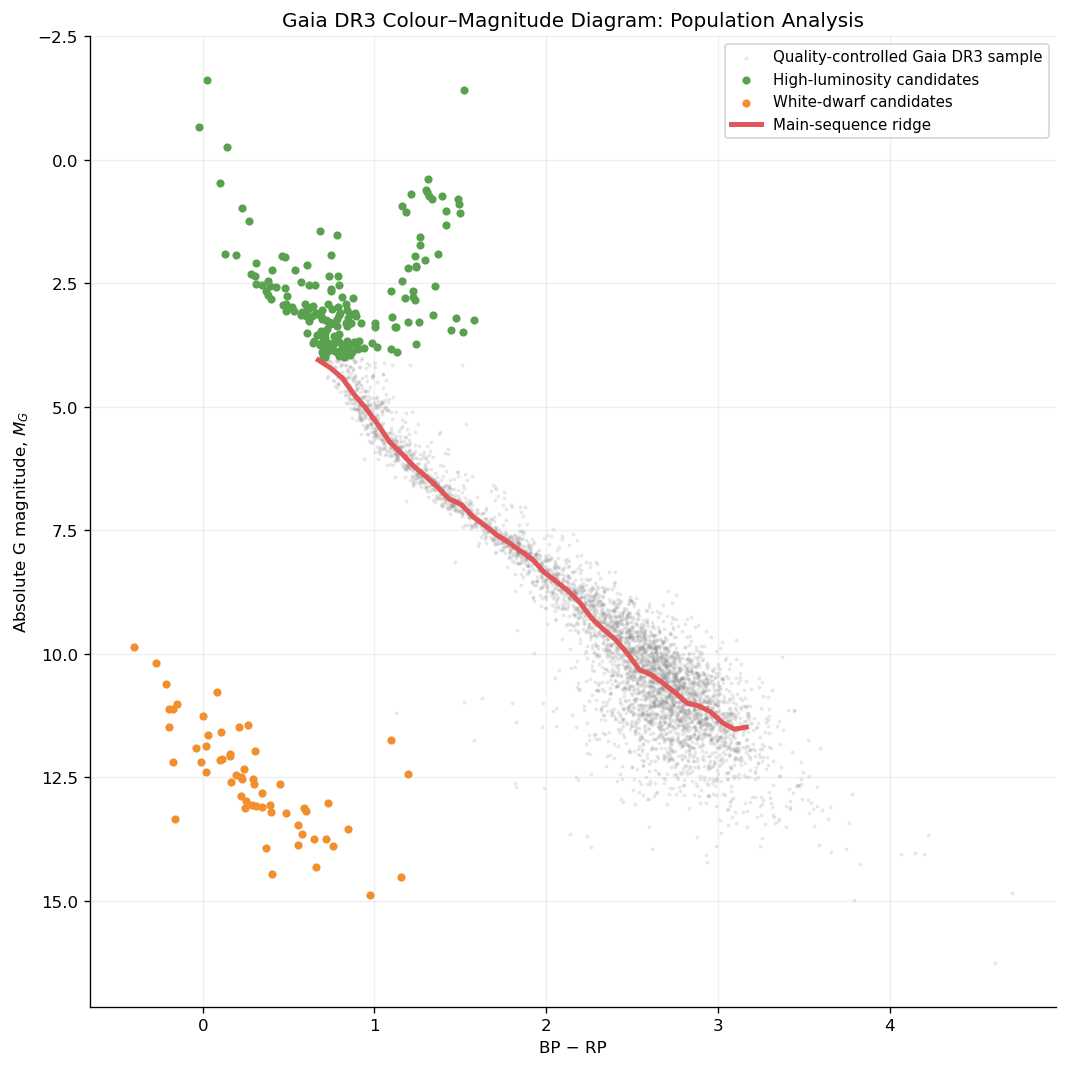

In [15]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(
    final_analysis["BP_RP"],
    final_analysis["M_G"],
    s=5,
    alpha=0.18,
    color="#7F7F7F",
    linewidths=0,
    label="Quality-controlled Gaia DR3 sample",
)
ax.scatter(
    high_lum_data["BP_RP"], high_lum_data["M_G"],
    s=24, color="#59A14F", linewidths=0, label="High-luminosity candidates"
)
ax.scatter(
    wd_data["BP_RP"], wd_data["M_G"],
    s=24, color="#F28E2B", linewidths=0, label="White-dwarf candidates"
)
ax.plot(
    main_centres[valid_ridge_bins], main_median_mag[valid_ridge_bins],
    color="#E15759", linewidth=3, label="Main-sequence ridge"
)
ax.set_xlabel("BP − RP")
ax.set_ylabel(r"Absolute G magnitude, $M_G$")
ax.set_title("Gaia DR3 Colour–Magnitude Diagram: Population Analysis")
ax.invert_yaxis()
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

## 11. Conclusions

The supplied Gaia DR3 snapshot demonstrates a reproducible route from catalogue measurements to a quantitative stellar-population analysis.

- Starting from 5,000 nearby sources that already met the query-level astrometric criteria, the \(C^*\) photometric criterion produced a final sample of 4,681 sources.
- The final CMD shows the expected dominant main sequence, a bright high-luminosity region, and a separate faint-blue region selected as white-dwarf candidates.
- The main-sequence working region contains 4,211 sources. Its median ridge is represented by a third-order polynomial with RMSE \(\approx0.120\) mag.
- Individual stars are much broader than the median ridge (robust observed scatter \(\approx0.491\) mag). Strong residuals are primarily on the faint side.
- Requiring parallax S/N > 10 reduces faint-side residual outliers from 157 to 20. Thus, parallax precision is an important contributor to the apparent faint-side broadening, although it does not explain every surviving residual.

### Important limitations

This analysis uses direct parallax inversion, does not correct for extinction, and employs broad CMD candidate selections. It therefore provides an interpretable local-sample analysis, not a complete or definitive stellar-classification catalogue. The empirical polynomial is sample-dependent and should not be treated as a fundamental stellar-evolution relation.

